### **Problem statement**

- This problem is centered on Descriptive Statistics, which involves calculating the fundamental measures on the data with PySpark

- Descriptive statistics typically gives
  - the count of values on each column
  - Minimum and Maximum value of each column
  - Average value of each column
  - Standard Deviation (stddev) value of each column








### **Setting up Spark / Java environment variables : installing dependecies**

In [ ]:
# Importing the os module
import os

# Install OpenJDK environment to run spark
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# Download Apache Spark 3.5.0 with hadoop quietly
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz

# Extract the Spark package
!tar xf spark-3.5.0-bin-hadoop3.tgz

# Set JAVA_HOME environment path pointing to where OpenJDK is installed
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Set SPARK_HOME environment path pointing to where Spark is installed

os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"


In [ ]:
# Lists files and directories in current working directory

!ls

sample_data  spark-3.5.0-bin-hadoop3  spark-3.5.0-bin-hadoop3.tgz


In [ ]:
# Installing the findspark package - necessary to run spark from Jupyter Notebook

!pip install findspark

# Importing findspark library

import findspark

In [ ]:
# Initializing Pyspark - locates spark installation

findspark.init()

### **A higher level and a slightly more straight forward approach for Spark installation**

In [1]:
!pip install pyspark

### **Importing dependencies**

In [2]:
# Importing spark session from spark.sql to create Spark entry points

from pyspark.sql import SparkSession

In [3]:
# Calling the builder method and getOrCreate to create or
# retriev a SparkSession
# spark runs locally with available cores

spark = SparkSession.builder \
        .appName('Spark analytics') \
        .master('local[*]') \
        .getOrCreate()

In [4]:
# Elements of the created SparkSession
spark

In [5]:
# Importing required libraries from pyspark.sql for data manipulation

from pyspark.sql.functions import col, when, array
from pyspark.sql.types import *

In [6]:
# Importing required dependencies for data manipulation

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [7]:
# Dependencies to import required files from Google Drive to Google Colab

from google.colab import drive

In [8]:
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Importing the dataset MetroPT3(AirCompressor).csv to a dataframe

df = spark.read.csv("/content/drive/MyDrive/MetroPT3(AirCompressor).csv", header = True, inferSchema = "true")



### **Basic Descriptive Statistics**

Dataset :https://archive.ics.uci.edu/dataset/791/metropt+3+dataset

In [10]:
# Retrieve the datatype of each column in the dataframe

df.dtypes

[('_c0', 'int'),
 ('timestamp', 'timestamp'),
 ('TP2', 'double'),
 ('TP3', 'double'),
 ('H1', 'double'),
 ('DV_pressure', 'double'),
 ('Reservoirs', 'double'),
 ('Oil_temperature', 'double'),
 ('Motor_current', 'double'),
 ('COMP', 'double'),
 ('DV_eletric', 'double'),
 ('Towers', 'double'),
 ('MPG', 'double'),
 ('LPS', 'double'),
 ('Pressure_switch', 'double'),
 ('Oil_level', 'double'),
 ('Caudal_impulses', 'double')]

In [11]:
# Display the schema of the dataframe

df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- TP2: double (nullable = true)
 |-- TP3: double (nullable = true)
 |-- H1: double (nullable = true)
 |-- DV_pressure: double (nullable = true)
 |-- Reservoirs: double (nullable = true)
 |-- Oil_temperature: double (nullable = true)
 |-- Motor_current: double (nullable = true)
 |-- COMP: double (nullable = true)
 |-- DV_eletric: double (nullable = true)
 |-- Towers: double (nullable = true)
 |-- MPG: double (nullable = true)
 |-- LPS: double (nullable = true)
 |-- Pressure_switch: double (nullable = true)
 |-- Oil_level: double (nullable = true)
 |-- Caudal_impulses: double (nullable = true)



In [12]:
# Display the number of rows and columns in the DataFrame (shape of the dataset)

print("Shape of the dataset :", (df.count(), len(df.columns)))

Shape of the dataset : (1516948, 17)


In [13]:
# Display the first 5 rows of the DataFrame

df.show(5)

+---+-------------------+-------------------+-----+-----+-------------------+----------+-----------------+------------------+----+----------+------+---+---+---------------+---------+---------------+
|_c0|          timestamp|                TP2|  TP3|   H1|        DV_pressure|Reservoirs|  Oil_temperature|     Motor_current|COMP|DV_eletric|Towers|MPG|LPS|Pressure_switch|Oil_level|Caudal_impulses|
+---+-------------------+-------------------+-----+-----+-------------------+----------+-----------------+------------------+----+----------+------+---+---+---------------+---------+---------------+
|  0|2020-02-01 00:00:00|-0.0120000000000004|9.358| 9.34|-0.0240000000000009|     9.358|53.60000000000001|              0.04| 1.0|       0.0|   1.0|1.0|0.0|            1.0|      1.0|            1.0|
| 10|2020-02-01 00:00:10|-0.0139999999999993|9.348|9.332|-0.0219999999999984|     9.348|53.67500000000001|              0.04| 1.0|       0.0|   1.0|1.0|0.0|            1.0|      1.0|            1.0|
| 20|

In [14]:
# Display the descriptive statistics of 'TP3' and 'Oil_Temperature' Column with
# select method

df.select('TP3','Oil_temperature').describe().show()

+-------+------------------+------------------+
|summary|               TP3|   Oil_temperature|
+-------+------------------+------------------+
|  count|           1516948|           1516948|
|   mean| 8.984610701223607|  62.6441817386006|
| stddev|0.6390950863089512| 6.516261089443435|
|    min|0.7300000000000004|15.400000000000006|
|    max|            10.302| 89.05000000000001|
+-------+------------------+------------------+



In [15]:
# Display the descriptive statistics of 'Motor_current' column with the select method

df.select('Motor_current').describe().show()

+-------+------------------+
|summary|     Motor_current|
+-------+------------------+
|  count|           1516948|
|   mean|2.0501708034821133|
| stddev|2.3020534138867643|
|    min|0.0199999999999995|
|    max|             9.295|
+-------+------------------+



### **Aggregation Function**

In [16]:
# Use of 'agg' method to display the maximum value of 'Motor_current' column

df.agg({'Motor_current':'max'}).show()

+------------------+
|max(Motor_current)|
+------------------+
|             9.295|
+------------------+



In [17]:
# Use of 'agg' method to display the minimum value of 'DV_pressure' column

df.agg({'DV_pressure':'min'}).show()

+----------------+
|min(DV_pressure)|
+----------------+
|          -0.032|
+----------------+



In [18]:
# Use of 'agg' method to display the average (mean) value of Reservoir's column

average = df.agg({'Reservoirs':'mean'}).show()

+---------------+
|avg(Reservoirs)|
+---------------+
|8.9852334437313|
+---------------+



In [19]:
# Calculation of median with Quantile probability, approxQuantile method
# and df.stat attribute

# The quantitle probability of 0.5 is the median with an error tolerance of 0.01

quantile_probability = [0.5]

quantile_value = df.stat.approxQuantile("Oil_Temperature", quantile_probability, 0.01)

median  = quantile_value

median

[62.7]

In [20]:
# calculation of standard deviation of 'TP2' column with agg method

df.agg({'TP2':'stddev'}).show()

+-----------------+
|      stddev(TP2)|
+-----------------+
|3.250929680703738|
+-----------------+



In [21]:
# Generating an extended statistical summary with df.select() and summary() methods
# for selected columns

# the extended summary table includes median(50th percentile) among other related
# statistical information.

df.select('DV_pressure','Reservoirs','Oil_temperature','Motor_current').summary().show()

+-------+-------------------+------------------+------------------+------------------+
|summary|        DV_pressure|        Reservoirs|   Oil_temperature|     Motor_current|
+-------+-------------------+------------------+------------------+------------------+
|  count|            1516948|           1516948|           1516948|           1516948|
|   mean|0.05595618966559176|   8.9852334437313|  62.6441817386006|2.0501708034821133|
| stddev|0.38240154603542426|0.6383070418596162| 6.516261089443435|2.3020534138867643|
|    min|             -0.032|0.7119999999999997|15.400000000000006|0.0199999999999995|
|    25%|-0.0219999999999984|             8.494|57.775000000000006|              0.04|
|    50%|-0.0199999999999995|              8.96| 62.72500000000001|0.0449999999999999|
|    75%|-0.0180000000000006|             9.492| 67.25000000000001| 3.807500000000001|
|    max|              9.844|              10.3| 89.05000000000001|             9.295|
+-------+-------------------+--------------

### **Filtering and Slicing the DataFrame with an index**

In [22]:
# Retrieve the dataframe column names starting with column three, through slicing

df.columns[2:]

['TP2',
 'TP3',
 'H1',
 'DV_pressure',
 'Reservoirs',
 'Oil_temperature',
 'Motor_current',
 'COMP',
 'DV_eletric',
 'Towers',
 'MPG',
 'LPS',
 'Pressure_switch',
 'Oil_level',
 'Caudal_impulses']

In [23]:
# Filtering 'Motor_current' column - with df.filter method.

df_1 = df.filter('Motor_current > 7')

df_1.show(10)


+-------+-------------------+-------------------+-----+------------------+-------------------+----------+-----------------+-----------------+----+----------+------+---+---+---------------+---------+---------------+
|    _c0|          timestamp|                TP2|  TP3|                H1|        DV_pressure|Reservoirs|  Oil_temperature|    Motor_current|COMP|DV_eletric|Towers|MPG|LPS|Pressure_switch|Oil_level|Caudal_impulses|
+-------+-------------------+-------------------+-----+------------------+-------------------+----------+-----------------+-----------------+----+----------+------+---+---+---------------+---------+---------------+
| 109760|2020-02-02 15:11:34|-0.0120000000000004|8.052|             6.924|-0.0180000000000006|     8.054|           56.375|7.357499999999998| 0.0|       1.0|   0.0|0.0|0.0|            1.0|      1.0|            1.0|
| 534360|2020-02-08 06:41:08|-0.0120000000000004|8.048| 6.034000000000001|-0.0180000000000006|     8.054|57.82499999999999|           8.2925

### **Conversion to Pandas dataframe for visualization with Seaborn**

To visualize the dataframe with Seaborn, it is essential to convert the PySpark dataframe to a Pandas dataframe - since PySpark doesn't natively support Seaborn for visualizations

In [24]:
# Conversion of the PySpark dataframe to a Pandas dataframe

df_pandas = df.toPandas()

In [25]:
df_pandas.dtypes

,0
_c0,int32
timestamp,datetime64[ns]
TP2,float64
TP3,float64
H1,float64
DV_pressure,float64
Reservoirs,float64
Oil_temperature,float64
Motor_current,float64
COMP,float64


(array([18293., 18322., 18353., 18383., 18414., 18444., 18475., 18506.]),
 [Text(18293.0, 0, '2020-02'),
  Text(18322.0, 0, '2020-03'),
  Text(18353.0, 0, '2020-04'),
  Text(18383.0, 0, '2020-05'),
  Text(18414.0, 0, '2020-06'),
  Text(18444.0, 0, '2020-07'),
  Text(18475.0, 0, '2020-08'),
  Text(18506.0, 0, '2020-09')])

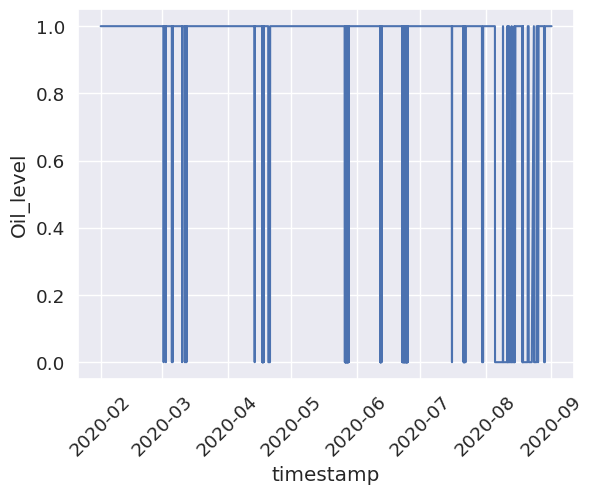

In [26]:
# Visualizing the data with Seaborn library
sns.set(font_scale= 1.2)
sns.lineplot(x = "timestamp", y = "Oil_level", data = df_pandas)
plt.xticks(rotation = 45)

### **Quiz - Calculate the Mode of the DV_electric column**

In [27]:
# Calculation of mode of a PySpark DataFrame

# Grouping by the DV_electric column, counting occurrances and ordering by the count.

mode_ = df.groupby("DV_eletric").count().orderBy('count', ascending = False).first()[0]

In [28]:
mode_

0.0